In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("final_airplane.csv")

C:\Users\chira\AppData\Local\Temp\ipykernel_15892\4292287716.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("final_airplane.csv")


In [3]:
df.shape


(5613655, 45)

In [4]:
df.columns.tolist()

['DEPARTURES_SCHEDULED',
 'DEPARTURES_PERFORMED',
 'PAYLOAD',
 'SEATS',
 'PASSENGERS',
 'FREIGHT',
 'MAIL',
 'DISTANCE',
 'RAMP_TO_RAMP',
 'AIR_TIME',
 'UNIQUE_CARRIER',
 'AIRLINE_ID',
 'UNIQUE_CARRIER_NAME',
 'UNIQUE_CARRIER_ENTITY',
 'REGION',
 'CARRIER',
 'CARRIER_NAME',
 'CARRIER_GROUP',
 'CARRIER_GROUP_NEW',
 'ORIGIN_AIRPORT_ID',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN_CITY_MARKET_ID',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_ABR',
 'ORIGIN_STATE_FIPS',
 'ORIGIN_STATE_NM',
 'ORIGIN_WAC',
 'DEST_AIRPORT_ID',
 'DEST_AIRPORT_SEQ_ID',
 'DEST_CITY_MARKET_ID',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_ABR',
 'DEST_STATE_FIPS',
 'DEST_STATE_NM',
 'DEST_WAC',
 'AIRCRAFT_GROUP',
 'AIRCRAFT_TYPE',
 'AIRCRAFT_CONFIG',
 'YEAR',
 'QUARTER',
 'MONTH',
 'DISTANCE_GROUP',
 'CLASS']

In [5]:
needed_cols = ['YEAR', 'MONTH', 'ORIGIN', 'DEST', 'UNIQUE_CARRIER', 'PASSENGERS']

df_clean = df[needed_cols]
print(df_clean.shape)
# df_clean.isnull().sum()

(5613655, 6)


In [6]:
df_clean.head()


,YEAR,MONTH,ORIGIN,DEST,UNIQUE_CARRIER,PASSENGERS
0,2010,10,ANC,ANC,7H,0.0
1,2010,1,RDV,SLQ,7N,0.0
2,2010,2,RDV,SLQ,7N,0.0
3,2010,3,RDV,SLQ,7N,0.0
4,2010,5,RDV,SLQ,7N,0.0


In [7]:
df_clean.isnull().sum()


YEAR                0
MONTH               0
ORIGIN              0
DEST                0
UNIQUE_CARRIER    672
PASSENGERS          0
dtype: int64

In [8]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5613655 entries, 0 to 5613654
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   YEAR            int64  
 1   MONTH           int64  
 2   ORIGIN          object 
 3   DEST            object 
 4   UNIQUE_CARRIER  object 
 5   PASSENGERS      float64
dtypes: float64(1), int64(2), object(3)
memory usage: 257.0+ MB


In [9]:
df_clean.describe()

,YEAR,MONTH,PASSENGERS
count,5.613655e+06,5.613655e+06,5.613655e+06
mean,2.017258e+03,6.566603e+00,1.870598e+03
std,4.360082e+00,3.454399e+00,3.865330e+03
min,2.010000e+03,1.000000e+00,0.000000e+00
25%,2.014000e+03,4.000000e+00,7.000000e+00
50%,2.017000e+03,7.000000e+00,2.520000e+02
75%,2.021000e+03,1.000000e+01,2.186000e+03
max,2.024000e+03,1.200000e+01,9.577700e+04


In [10]:
# filter directly for your route while data is still loading, if possible
route_df = df_clean[(df_clean['ORIGIN'] == 'JFK') & (df_clean['DEST'] == 'LAX')]
route_df.shape

(1756, 6)

In [11]:
route_df.columns

Index(['YEAR', 'MONTH', 'ORIGIN', 'DEST', 'UNIQUE_CARRIER', 'PASSENGERS'], dtype='object')

In [12]:
route_df["UNIQUE_CARRIER"].value_counts()

UNIQUE_CARRIER
DL     595
AA     282
B6     274
QF     138
UA     124
VX     117
AS     109
5Y      25
FX      15
KAQ     13
PR       6
SY       6
KE       6
HA       5
MU       4
N8       4
CI       3
L7       3
SV       3
CX       2
1BQ      2
LH       2
BR       2
WI       2
LA       2
8C       1
0WQ      1
CC       1
US       1
EY       1
TK       1
1UQ      1
27Q      1
34Q      1
LY       1
AC       1
LP       1
Name: count, dtype: int64

In [13]:
route_df.head()

,YEAR,MONTH,ORIGIN,DEST,UNIQUE_CARRIER,PASSENGERS
53535,2010,10,JFK,LAX,B6,101.0
62672,2010,6,JFK,LAX,DL,192.0
62727,2010,11,JFK,LAX,DL,127.0
62755,2010,12,JFK,LAX,DL,205.0
63480,2010,5,JFK,LAX,DL,174.0


In [14]:
monthly = route_df.groupby(["YEAR","MONTH"])["PASSENGERS"].sum().reset_index()

In [15]:
monthly.head(12)

,YEAR,MONTH,PASSENGERS
0,2010,1,113691.0
1,2010,2,93335.0
2,2010,3,121022.0
3,2010,4,118204.0
4,2010,5,125737.0
5,2010,6,127215.0
6,2010,7,142090.0
7,2010,8,139480.0
8,2010,9,126395.0
9,2010,10,135135.0


In [16]:
# year_total = route_df.groupby("YEAR")["PASSENGERS"].sum().reset_index()

In [17]:
# year_total

In [18]:
monthly["DATE"] = pd.to_datetime(monthly["YEAR"].astype(str)+ "-" + monthly["MONTH"].astype
                                (str)+ "-01")

In [19]:
monthly

,YEAR,MONTH,PASSENGERS,DATE
0,2010,1,113691.0,2010-01-01
1,2010,2,93335.0,2010-02-01
2,2010,3,121022.0,2010-03-01
3,2010,4,118204.0,2010-04-01
4,2010,5,125737.0,2010-05-01
...,...,...,...,...
175,2024,8,120738.0,2024-08-01
176,2024,9,117718.0,2024-09-01
177,2024,10,126079.0,2024-10-01
178,2024,11,117519.0,2024-11-01


In [20]:
import matplotlib.pyplot as plt

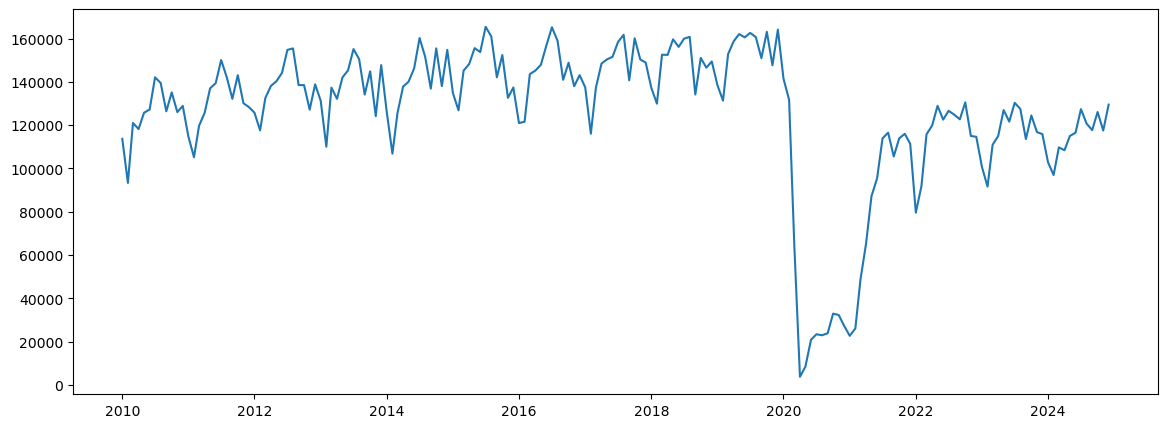

In [21]:
plt.figure(figsize=(14,5))
plt.plot(monthly["DATE"],monthly["PASSENGERS"])

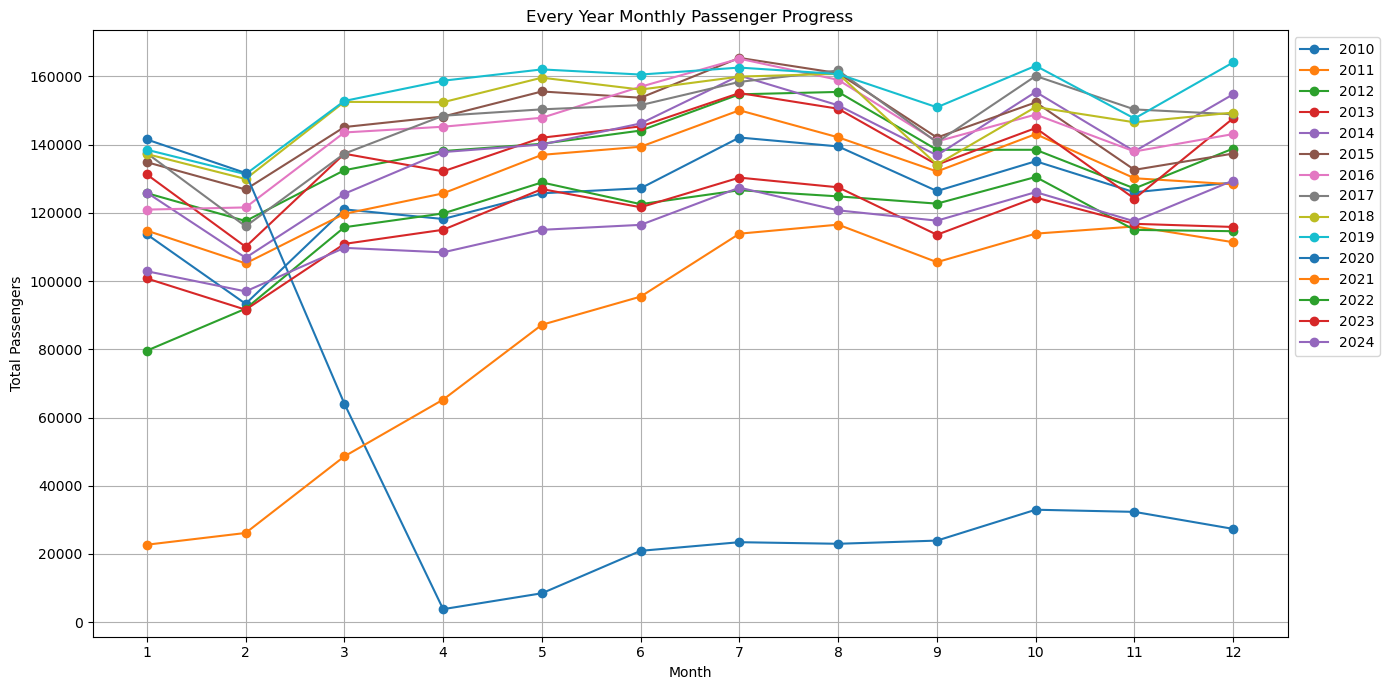

In [22]:
plt.figure(figsize=(14,7))


for year in sorted(monthly["YEAR"].unique()):
    year_data = monthly[monthly["YEAR"] == year]

    plt.plot(year_data["MONTH"],year_data["PASSENGERS"],marker= "o",label =year)


plt.xlabel("Month")
plt.ylabel("Total Passengers")
plt.title("Every Year Monthly Passenger Progress")
plt.xticks(range(1, 13))
# plt.ticklabel_format(style="plain", axis="y")
# plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.legend(bbox_to_anchor=(1,1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# pip! install statsmodels 
from statsmodels.tsa.seasonal import seasonal_decompose



In [24]:
# now index ab 0,1,2,3 nhi h hume seasonal decompose mei dena h toh humko date ko index bana
# banana padega
monthly_index = monthly.set_index('DATE')
decomposition = seasonal_decompose(monthly_index["PASSENGERS"],model="additive",period=12)
# monthly_index


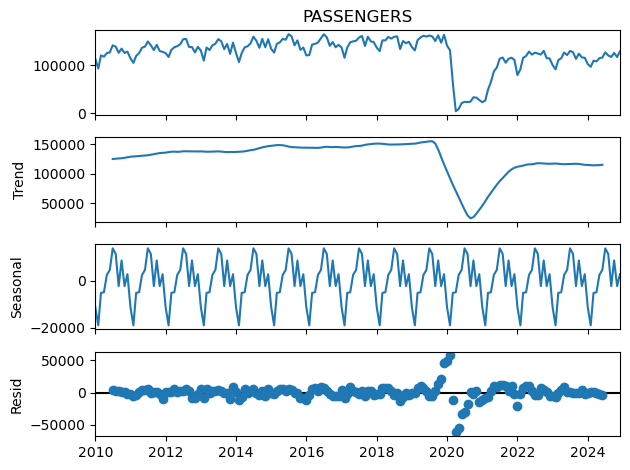

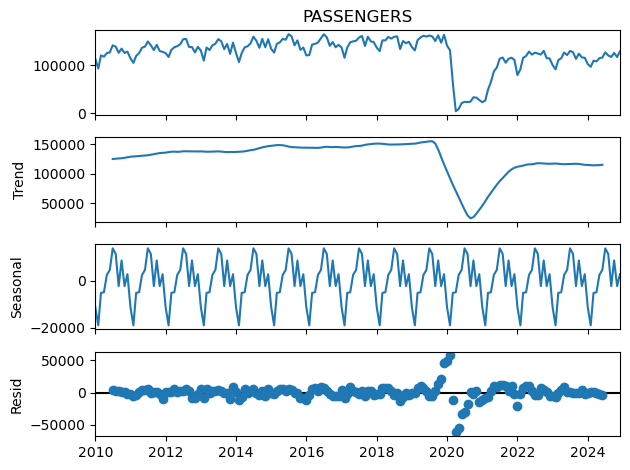

In [25]:
decomposition.plot()

we cant use linear regression here bcz yee time series data h yha linear work nhi krega toh hume 
time series waala model use krna hoga "ARIMA" 

if we have to use arima huma staionarity data chaiye hota h uske liye pehle adf test krna hoga data sationarity h ya nhi
agr nhi h toh diff leke banana padta h  (if p value >0.05 not stationary , if <0.05 stationary )
ADF < critical value → stationary
ADF > critical value → NOT stationary

In [26]:
from statsmodels.tsa.stattools import adfuller 

In [27]:
result = adfuller(monthly_index["PASSENGERS"])
result

(np.float64(-2.549235989219583),
 np.float64(0.10394947451274639),
 13,
 166,
 {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 np.float64(3573.7906520689703))

In [28]:
monthly_diff = monthly_index["PASSENGERS"].diff().dropna()

In [29]:
result = adfuller(monthly_diff)
result

(np.float64(-3.9786787936719947),
 np.float64(0.0015263637450848315),
 12,
 166,
 {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 np.float64(3557.008641996445))

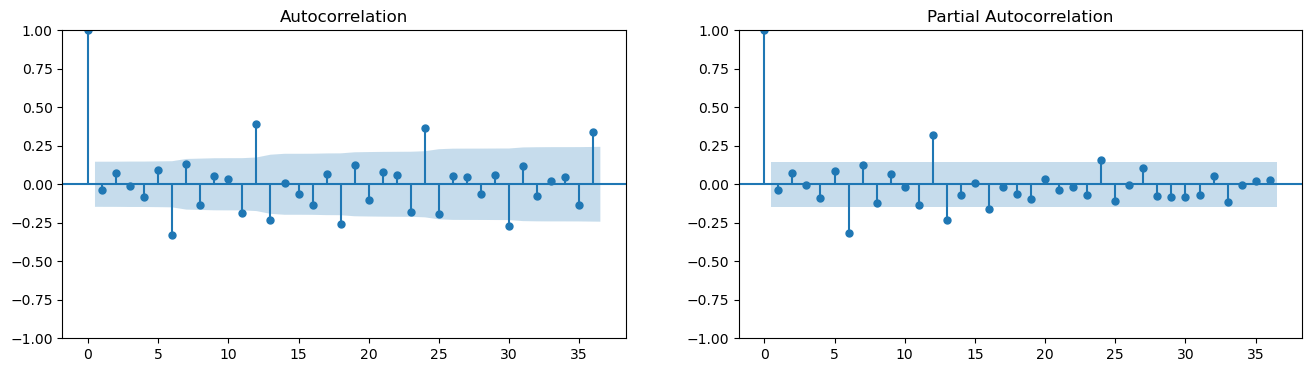

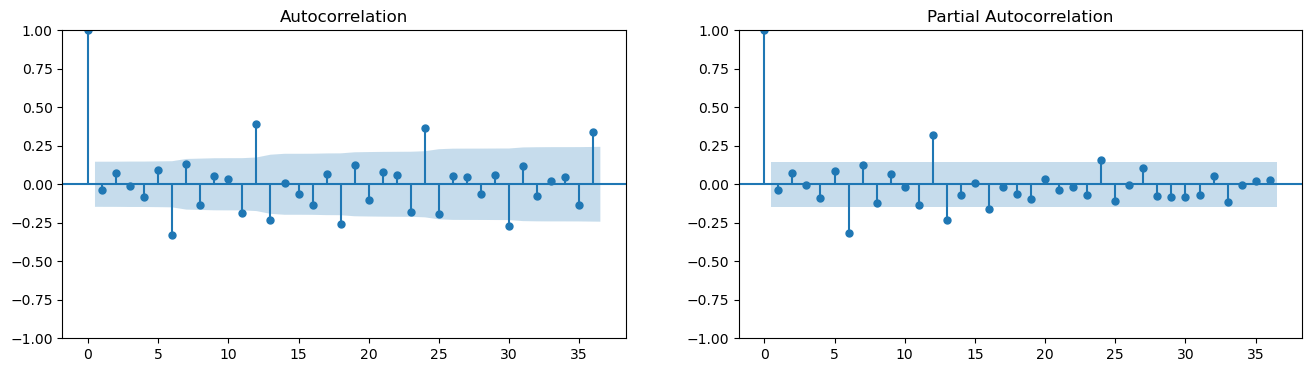

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16,4))
plot_acf(monthly_diff, lags=36, ax=axes[0])
plot_pacf(monthly_diff, lags=36, ax=axes[1])

In [31]:
!pip install pmdarima

In [32]:
from pmdarima import auto_arima,pm

ImportError: cannot import name 'pm' from 'pmdarima' (C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\pmdarima\__init__.py)

In [33]:

model = auto_arima(
    monthly_index['PASSENGERS'],
    seasonal=True,
    m=12,                
    trace=True,          
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3923.063, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3911.328, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3915.471, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3921.073, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3923.570, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3903.933, Time=0.23 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3899.203, Time=0.26 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3898.139, Time=0.17 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3915.526, Time=0.15 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3899.303, Time=0.32 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3910.015, Time=0.22 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=3901.031, Time=0.35 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=3895.604, Time=0.14 sec
 ARIMA(0,1,0)(0,0,1)[12]

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  180
Model:             SARIMAX(0, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1941.575
Date:                              Thu, 16 Jul 2026   AIC                           3889.150
Time:                                      14:28:06   BIC                           3898.712
Sample:                                  01-01-2010   HQIC                          3893.027
                                       - 12-01-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.9182      0.044     21.098      0.000       0.833       1.003
ma.S.L12      -0.7916      0.069    -11.409      0.000      -0.928      -0.656
sigma2      1.581e+08   2.93e-10   5.39e+17      0.000    1.58e+08    1.58e+08
===================================================================================
Ljung-Box (L1) (Q):                   2.48   Jarque-Bera (JB):              1181.40
Prob(Q):                              0.11   Prob(JB):                         0.00
Heteroskedasticity (H):               1.75   Skew:                            -2.28
Prob(H) (two-sided):                  0.03   Kurtosis:                        14.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.61e+33. Standard errors may be unstable.
"""

In [34]:
import pmdarima as pm

# yee sarima hi h bs use arima ke naam pr rhe h 
final_model = pm.ARIMA(order=(0,1,1),seasonal_order =(1,1,1,12))
# final_model = pm.ARIMA(order=(1,1,1),seasonal_order =(1,0,1,12))
final_model.fit(monthly_index["PASSENGERS"])

n_periods =12

forecast, conf_int = final_model.predict(n_periods=n_periods, return_conf_int = True )



C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [35]:
forecast

2025-01-01    117373.996191
2025-02-01    112732.950422
2025-03-01    125006.904683
2025-04-01    124046.219765
2025-05-01    132551.258970
2025-06-01    133437.381014
2025-07-01    142535.941345
2025-08-01    139296.927543
2025-09-01    131482.240506
2025-10-01    141244.110005
2025-11-01    132823.068961
2025-12-01    138195.804102
Freq: MS, dtype: float64

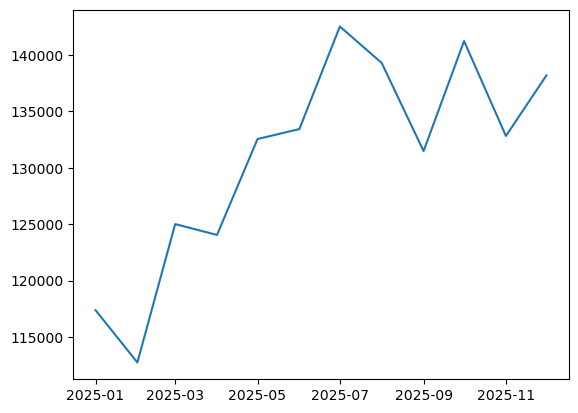

In [36]:
plt.plot(forecast)


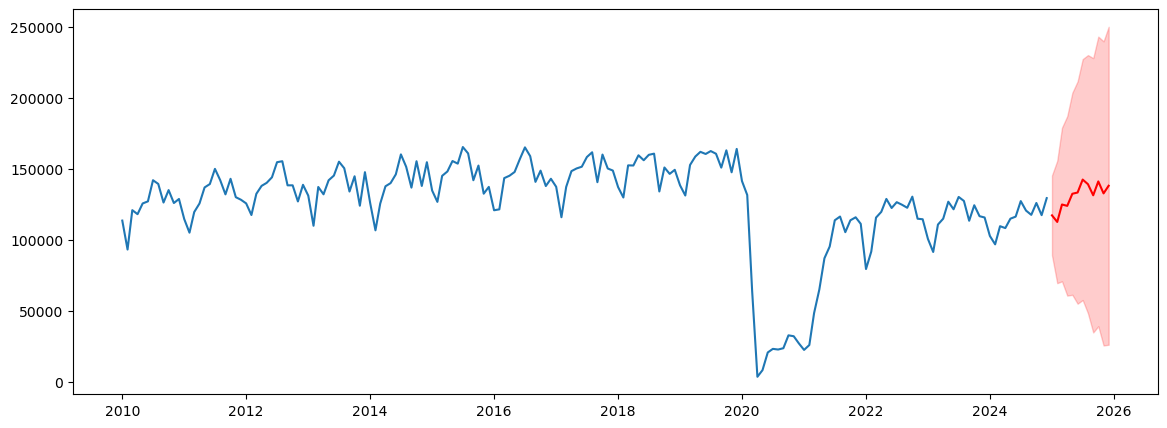

In [37]:
plt.figure(figsize=(14,5))
# remember monthly_index ka index hume date set kia tha
plt.plot(monthly_index.index,monthly_index["PASSENGERS"],label="actual")

plt.plot(forecast.index,forecast,label="forest",color="red")

plt.fill_between(forecast.index, conf_int[:,0], conf_int[:,1], color='red', alpha=0.2)

EVALUATION MATRIX


In [38]:
train =  monthly_index[monthly_index.index < '01-01-2024']
test =  monthly_index[monthly_index.index >= '01-01-2024']

In [39]:
train.shape

(168, 3)

In [40]:
test.shape

(12, 3)

now use train data to refit the model


In [41]:
eval_model = pm.ARIMA(order= (0,1,1),seasonal_order=(0,1,1,12))
eval_model.fit(train["PASSENGERS"])

n_periods = len(test)

test_forest,train_config_int = eval_model.predict(n_periods=n_periods, return_conf_int = True)

C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
test_forest

2024-01-01     98636.612138
2024-02-01     95950.576694
2024-03-01    108670.666390
2024-04-01    108413.701508
2024-05-01    119006.245920
2024-06-01    117881.608920
2024-07-01    125618.511000
2024-08-01    124120.276850
2024-09-01    114027.951637
2024-10-01    123974.046952
2024-11-01    115706.947067
2024-12-01    115426.082712
Freq: MS, dtype: float64

In [43]:
predicted = test_forest
actual = test["PASSENGERS"]

In [44]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

In [45]:
rmse = root_mean_squared_error(actual,predicted)
mape = mean_absolute_percentage_error(actual,predicted)*100

In [46]:
rmse

4758.194264988952

In [47]:
mape

2.6866277592311456

In [49]:
test.describe()

,YEAR,MONTH,PASSENGERS
count,12.0,12.000000,12.000000
mean,2024.0,6.500000,115707.250000
std,0.0,3.605551,9868.886012
min,2024.0,1.000000,96981.000000
25%,2024.0,3.750000,109412.250000
50%,2024.0,6.500000,117001.000000
75%,2024.0,9.250000,122073.250000
max,2024.0,12.000000,129487.000000


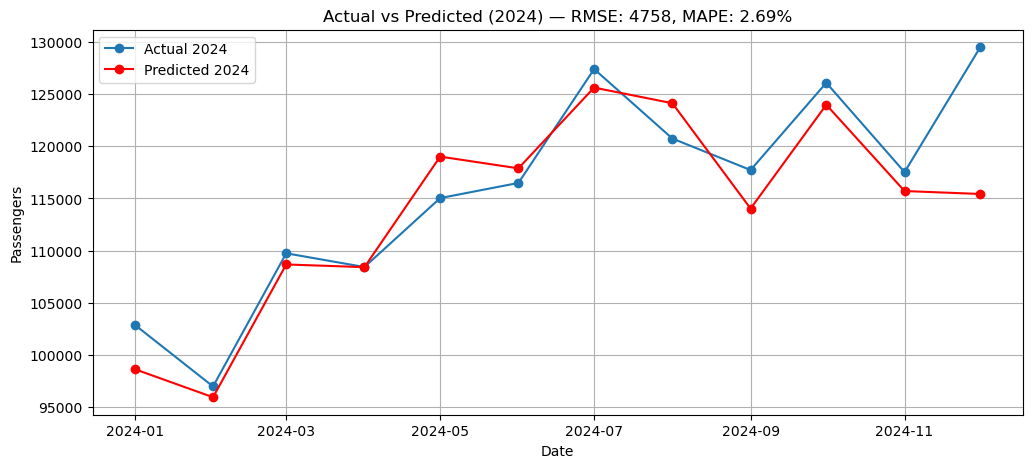

In [50]:
plt.figure(figsize=(12,5))

plt.plot(test.index, actual, label='Actual 2024', marker='o')
plt.plot(test.index, predicted, label='Predicted 2024', marker='o', color='red')

plt.title(f'Actual vs Predicted (2024) — RMSE: {rmse:.0f}, MAPE: {mape:.2f}%')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [51]:

residuals_v2 = eval_model.arima_res_.resid

from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test_v2 = acorr_ljungbox(residuals_v2, lags=[12], return_df=True)
print(lb_test_v2)

      lb_stat  lb_pvalue
12  19.805423   0.070857


# ---------------------------------------------------------------------


FULL DATASET FIT NOW

In [92]:
final_model = pm.ARIMA(order=(0,1,1), seasonal_order=(0,1,1,12))
final_model.fit(monthly_index['PASSENGERS'])

print(final_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  180
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1812.149
Date:                            Thu, 16 Jul 2026   AIC                           3632.298
Time:                                    14:28:15   BIC                           3644.770
Sample:                                01-01-2010   HQIC                          3637.360
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     24.4724    632.111      0.039      0.969   -1214.441    1263.386
ma.L1          0.1681      0.044   

C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\chira\anaconda3\envs\chiragenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [93]:
n_periods = 18  # forecast 18 months ahead

forecast_final, conf_int_final = final_model.predict(n_periods=n_periods, return_conf_int=True)

print(forecast_final)

2025-01-01    116107.846676
2025-02-01    112445.477839
2025-03-01    125281.719982
2025-04-01    124783.541973
2025-05-01    134130.636446
2025-06-01    134148.464914
2025-07-01    143167.400993
2025-08-01    140068.592067
2025-09-01    132592.557035
2025-10-01    142188.485013
2025-11-01    133999.831868
2025-12-01    138206.293335
2026-01-01    123543.071543
2026-02-01    119905.175115
2026-03-01    132765.889667
2026-04-01    132292.184068
2026-05-01    141663.750951
2026-06-01    141706.051828
Freq: MS, dtype: float64


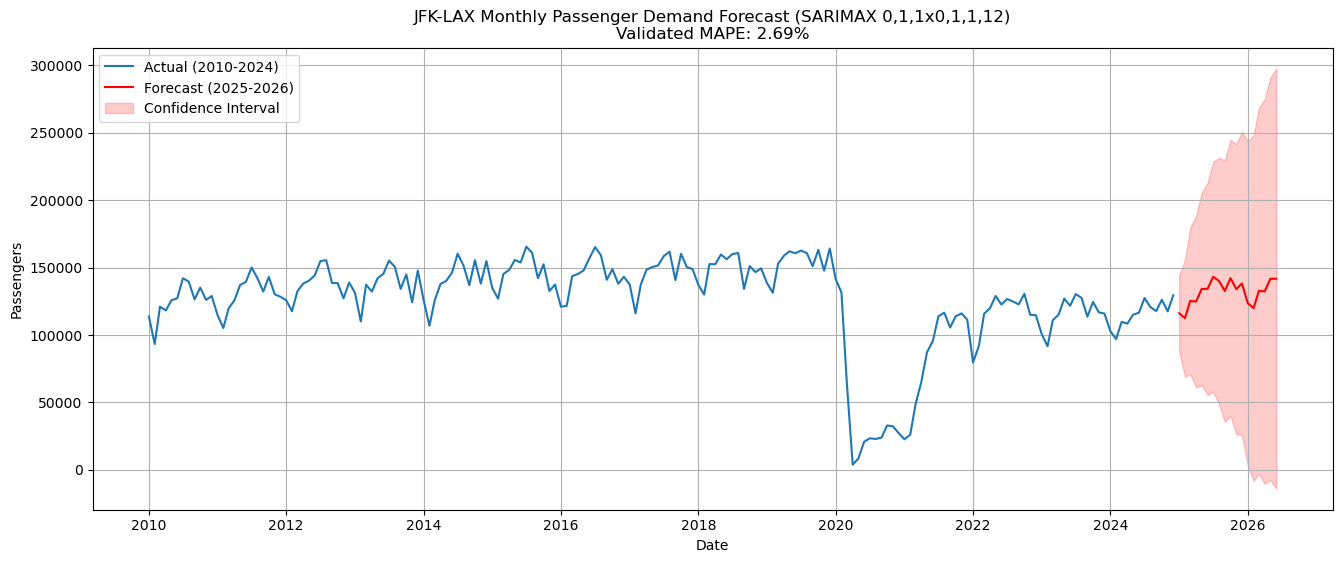

In [94]:
plt.figure(figsize=(16,6))

plt.plot(monthly_index.index, monthly_index['PASSENGERS'], label='Actual (2010-2024)')
plt.plot(forecast_final.index, forecast_final, label='Forecast (2025-2026)', color='red')
plt.fill_between(forecast_final.index, conf_int_final[:,0], conf_int_final[:,1], color='red', alpha=0.2, label='Confidence Interval')

plt.title('JFK-LAX Monthly Passenger Demand Forecast (SARIMAX 0,1,1x0,1,1,12)\nValidated MAPE: 2.69%')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

FINAL TASK :------


In [97]:
df_clean  = df.copy()

In [98]:
route_monthly_all = df_clean.groupby(["ORIGIN","DEST","YEAR","MONTH"])["PASSENGERS"].sum().reset_index()

In [99]:
route_monthly_all.head()

,ORIGIN,DEST,YEAR,MONTH,PASSENGERS
0,01A,A43,2020,8,4.0
1,01A,A43,2020,10,3.0
2,01A,A43,2020,11,3.0
3,01A,A43,2021,5,1.0
4,01A,A43,2021,8,3.0


In [105]:
# route_monthly_all = route_monthly_all.sort_values(by=["ORIGIN","DEST","YEAR","MONTH"])

In [107]:

overrall_monthly = df_clean.groupby(["YEAR","MONTH"])["PASSENGERS"].sum().reset_index()

In [108]:
overrall_monthly["ORIGIN"] = "ALL"
overrall_monthly["DEST"] = "ALL"


In [111]:
# overrall_monthly.head()

In [112]:
# route_monthly_all.head()

In [113]:
combined_data =  pd.concat([route_monthly_all,overrall_monthly],ignore_index=True)

In [115]:
combined_data.shape

(1973008, 5)

In [120]:
combined_data["ORIGIN"].nunique()

2166

In [121]:
route_totals = route_monthly_all.groupby(["ORIGIN","DEST"])["PASSENGERS"].sum().reset_index()

In [122]:
active_routes = route_totals[route_totals["PASSENGERS"] > 500000]

In [123]:
active_routes.shape

(3709, 3)

In [124]:
active_routes

,ORIGIN,DEST,PASSENGERS
517,ABE,ATL,808297.0
551,ABE,CLT,840349.0
646,ABE,ORD,596855.0
683,ABE,SFB,863516.0
738,ABI,DFW,1233624.0
...,...,...,...
95024,XNA,DFW,2408238.0
95076,XNA,IAH,708808.0
95142,XNA,ORD,1514700.0
95819,YKM,SEA,783010.0


In [125]:
active_routes_pairs = set(zip(active_routes["ORIGIN"],active_routes["DEST"]))

In [135]:
final_data = combined_data[combined_data.apply(
    lambda row : (row["ORIGIN"], row["DEST"]) in active_routes_pairs or row["ORIGIN"] == "ALL",axis=1)
]

In [136]:
final_data.shape

(650574, 5)

In [137]:
final_data.to_csv('route_monthly_data.csv', index=False)
print("Saved successfully")

Saved successfully
